## Librerias

In [1]:
import pandas as pd
import numpy as np

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Modelo
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

## Importar datos

In [4]:
df = pd.read_csv("dfSegmentado.csv")

# Vista rápida
print(df.head())
print(df.info())

   Identificador  Genero Estado_Civil  Edad Graduado      Profesion  \
0         462809    Male           No    22       No     Healthcare   
1         462643  Female          Yes    38      Yes       Engineer   
2         466315  Female          Yes    67      Yes       Engineer   
3         461735    Male          Yes    67      Yes         Lawyer   
4         462669  Female          Yes    40      Yes  Entertainment   

   Experiencia_Laboral Puntuacion_Gasto  Tamano_Familiar Segmento  
0                  1.0              Low              4.0        D  
1                  1.0          Average              3.0        A  
2                  1.0              Low              1.0        B  
3                  0.0             High              2.0        B  
4                  1.0             High              6.0        A  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ---

## Preprocesamiento

In [5]:
# Eliminar columnas irrelevantes si existen (ejemplo: ID)
df = df.drop(columns=["ID", "Identificador"], errors="ignore")

X = df.drop("Segmento", axis=1)
y = df["Segmento"]

In [6]:
categoricas = X.select_dtypes(include=["object"]).columns
numericas = X.select_dtypes(include=["int64", "float64"]).columns

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("num", "passthrough", numericas)
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
df.head()

,Genero,Estado_Civil,Edad,Graduado,Profesion,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Segmento
0,Male,No,22,No,Healthcare,1.0,Low,4.0,D
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,B
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,A


## Entrenamiento

In [19]:
# Aplicar preprocesamiento
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Modelo
modelo = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

modelo.fit(X_train_transformed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predicciones

In [20]:
y_pred = modelo.predict(X_test_transformed)

## Evaluaciones

In [21]:
print("Train Accuracy:", modelo.score(X_train_transformed, y_train))
print("Test Accuracy:", modelo.score(X_test_transformed, y_test))

Train Accuracy: 0.5206073752711496
Test Accuracy: 0.5148698884758365


In [22]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           A       0.41      0.48      0.45       394
           B       0.38      0.20      0.26       372
           C       0.53      0.60      0.56       394
           D       0.64      0.72      0.68       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.50      0.51      0.50      1614



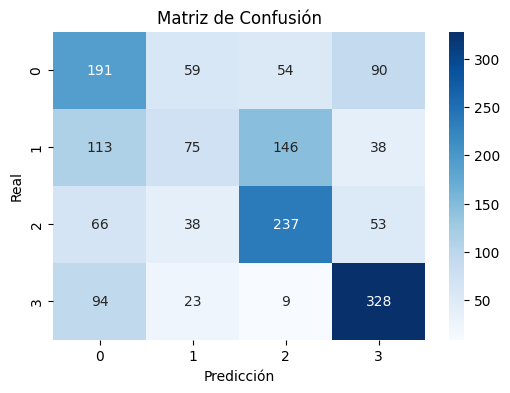

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

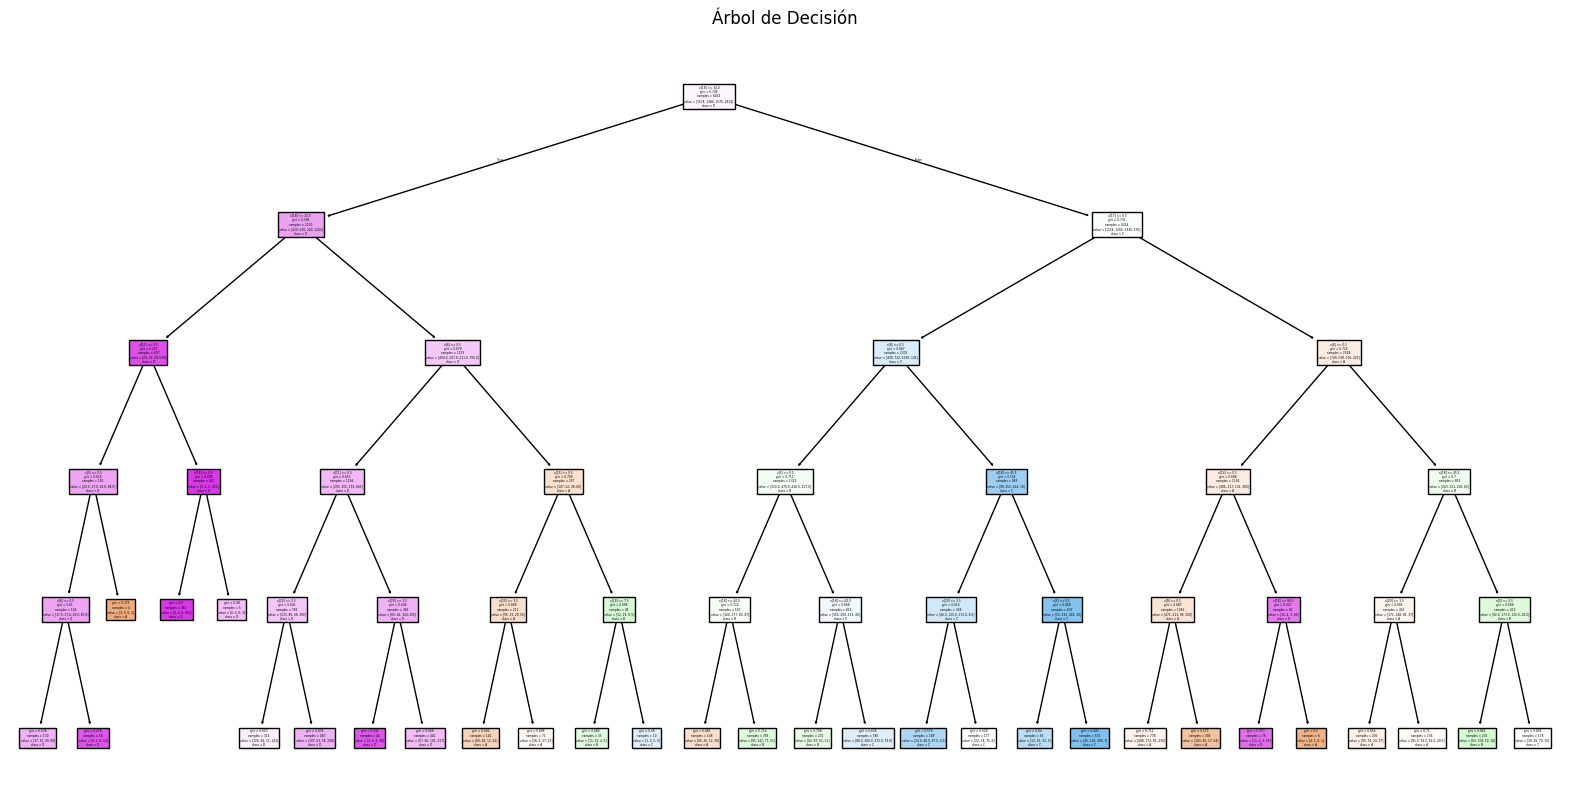

In [24]:
plt.figure(figsize=(20,10))
plot_tree(modelo, filled=True, feature_names=None, class_names=modelo.classes_)
plt.title("Árbol de Decisión")
plt.show()

In [28]:
importances = modelo.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names)
print(feat_imp.sort_values(ascending=False).head(10))

num__Edad                        0.538142
cat__Profesion_Artist            0.157223
cat__Puntuacion_Gasto_Low        0.154421
cat__Profesion_Healthcare        0.041753
cat__Graduado_Yes                0.033482
num__Tamano_Familiar             0.025456
cat__Profesion_Marketing         0.021719
cat__Profesion_Entertainment     0.015390
cat__Puntuacion_Gasto_Average    0.004659
cat__Genero_Female               0.004604
dtype: float64


## .

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_transformed, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [26]:
modelo = grid.best_estimator_

In [27]:
print(y.value_counts(normalize=True))

Segmento
D    0.281111
A    0.244422
C    0.244175
B    0.230293
Name: proportion, dtype: float64
